In [353]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import matplotlib.pyplot as plt
import time
import numpy as np
from scipy.fft import fft, fftfreq

LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [367]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-02-11 02:35:53,444 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-02-11 02:35:53,444 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600
2026-02-11 02:36:03,495 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-02-11 02:36:03,498 | INFO     |: Selecting device: F32F03E1-EF13-6043-59E7-D2AE8E670FC2 (name: Artemis BLE)
2026-02-11 02:36:04,340 | INFO     |: Connected to c0:42:0c:78:b8:49


In [291]:
ble.reload_config()

## ICM Sensor

In [184]:
times = []
accX = []
accY = []
accZ = []
raw_pitch = []
raw_roll = []
filt_pitch = []
filt_roll = []

def accl_notification_handler(sender, data: bytearray):
    s = ble.bytearray_to_string(data).split("|")
    if len(s) == 8:
        t = float(s[0][2:])
        x = float(s[1][2:])
        y = float(s[2][2:])
        z = float(s[3][2:])
        r_p = float(s[4][2:])
        r_r = float(s[5][2:])
        f_p = float(s[6][3:])
        f_r = float(s[7][3:])

        times.append(t)
        accX.append(x)
        accY.append(y)
        accZ.append(z)
        raw_pitch.append(r_p)
        raw_roll.append(r_r)
        filt_pitch.append(f_p)
        filt_roll.append(f_r)

        print (f"T={t:7.2f}   x={x:7.2f}   y={y:7.2f}   z={z:7.2f}   pitch={r_p:7.2f}°   roll={r_r:7.2f}°  filt_pitch={f_p:7.2f}°   filt_roll={f_r:7.2f}°")

In [39]:
ble.start_notify(ble.uuid["RX_STRING"], accl_notification_handler)

In [ ]:
ble.stop_notify(ble.uuid["RX_STRING"])

In [ ]:
times = []
accX = []
accY = []
accZ = []
raw_pitch = []
raw_roll = []
filt_pitch = []
filt_roll = []

ble.send_command(CMD.START_COLLECT_DATA, "")
time.sleep(5)
ble.send_command(CMD.GET_ACCL_READINGS, "")

T=1549389.00   x=  -4.39   y=  -9.28   z= 965.82   pitch=  -0.26°   roll=  -0.55°  filt_pitch=  -0.26°   filt_roll=  -0.55°
T=1549398.00   x=  -4.39   y=   3.42   z=1036.62   pitch=  -0.24°   roll=   0.19°  filt_pitch=  -0.26°   filt_roll=  -0.42°
T=1549404.00   x=  -9.28   y=  14.16   z=1071.29   pitch=  -0.50°   roll=   0.76°  filt_pitch=  -0.30°   filt_roll=  -0.21°
T=1549409.00   x= -23.93   y=   3.91   z=1063.48   pitch=  -1.29°   roll=   0.21°  filt_pitch=  -0.47°   filt_roll=  -0.14°
T=1549418.00   x= -17.09   y= -14.16   z= 970.70   pitch=  -1.01°   roll=  -0.83°  filt_pitch=  -0.56°   filt_roll=  -0.25°
T=1549423.00   x=   2.44   y=   8.30   z= 987.30   pitch=   0.14°   roll=   0.48°  filt_pitch=  -0.44°   filt_roll=  -0.13°
T=1549428.00   x=  -9.77   y= -27.34   z= 986.33   pitch=  -0.57°   roll=  -1.59°  filt_pitch=  -0.47°   filt_roll=  -0.37°
T=1549436.00   x=  -4.39   y= -16.60   z=1026.86   pitch=  -0.24°   roll=  -0.93°  filt_pitch=  -0.43°   filt_roll=  -0.46°
T=154944

## Accelerator Pitch & Roll

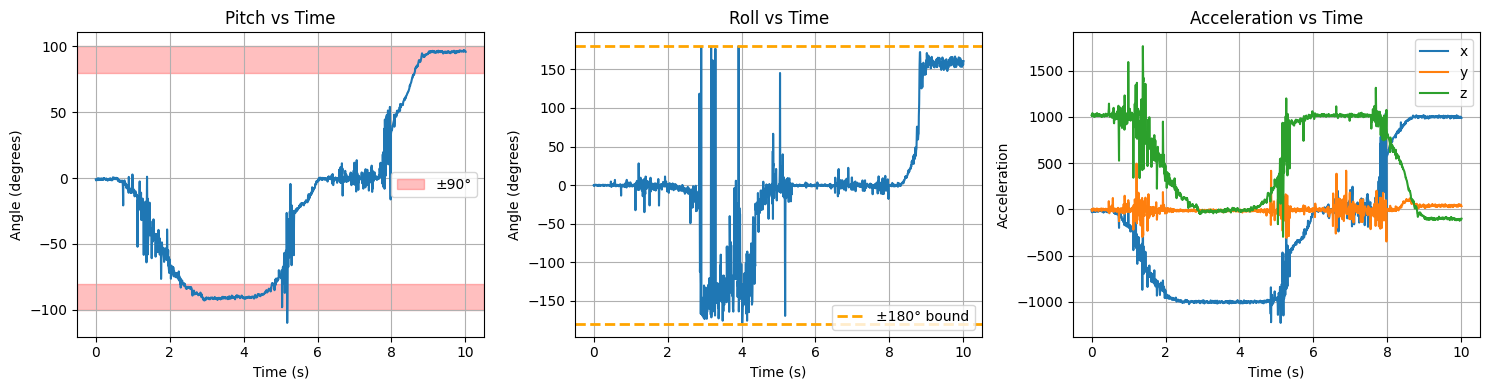

In [ ]:
# Prepare arrays
t = np.array(times)
t = t - t[0]
t = t / 1000.0
r_p = np.array(raw_pitch)
r_r = np.array(raw_roll)
x = np.array(accX)
y = np.array(accY)
z = np.array(accZ)

# Create a single figure with 1x3 subplots arranged horizontally
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pitch subplot
ax = axes[0]
ax.plot(t, p)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (degrees)')
ax.set_title('Pitch vs Time')
band = 10
ax.axhspan(90-band, 90+band, alpha=0.25, color='red', label='±90°')
ax.axhspan(-90-band, -90+band, alpha=0.25, color='red')
# ax.axhline(180,  color='orange', linestyle='--', linewidth=2, label='±180° bound')
# ax.axhline(-180, color='orange', linestyle='--', linewidth=2)
ax.grid(True)
ax.legend()

# Roll subplot
ax = axes[1]
ax.plot(t, r)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (degrees)')
ax.set_title('Roll vs Time')
# band = 10
# ax.axhspan(90-band, 90+band, alpha=0.25, color='red', label='±90°')
# ax.axhspan(-90-band, -90+band, alpha=0.25, color='red')
ax.axhline(180,  color='orange', linestyle='--', linewidth=2, label='±180° bound')
ax.axhline(-180, color='orange', linestyle='--', linewidth=2)
ax.grid(True)
ax.legend()

# Acceleration subplot
ax = axes[2]
ax.plot(t, x, label='x')
ax.plot(t, y, label='y')
ax.plot(t, z, label='z')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration')
ax.set_title('Acceleration vs Time')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

## Fourier Transform

In [181]:
# Prepare arrays
t = np.array(times)
t = t - t[0]
t = t / 1000.0
r_p = np.array(raw_pitch)
r_r = np.array(raw_roll)
f_p = np.array(filt_pitch)
f_r = np.array(filt_roll)

# Calculate sampling rate (Hz)
dt = np.mean(np.diff(t))  # Average time step
sampling_rate = 1.0 / dt if dt > 0 else 1.0

# Number of samples
N = len(t)

# Get frequency array (only positive frequencies)
freq = fftfreq(N, dt)[:N//2]

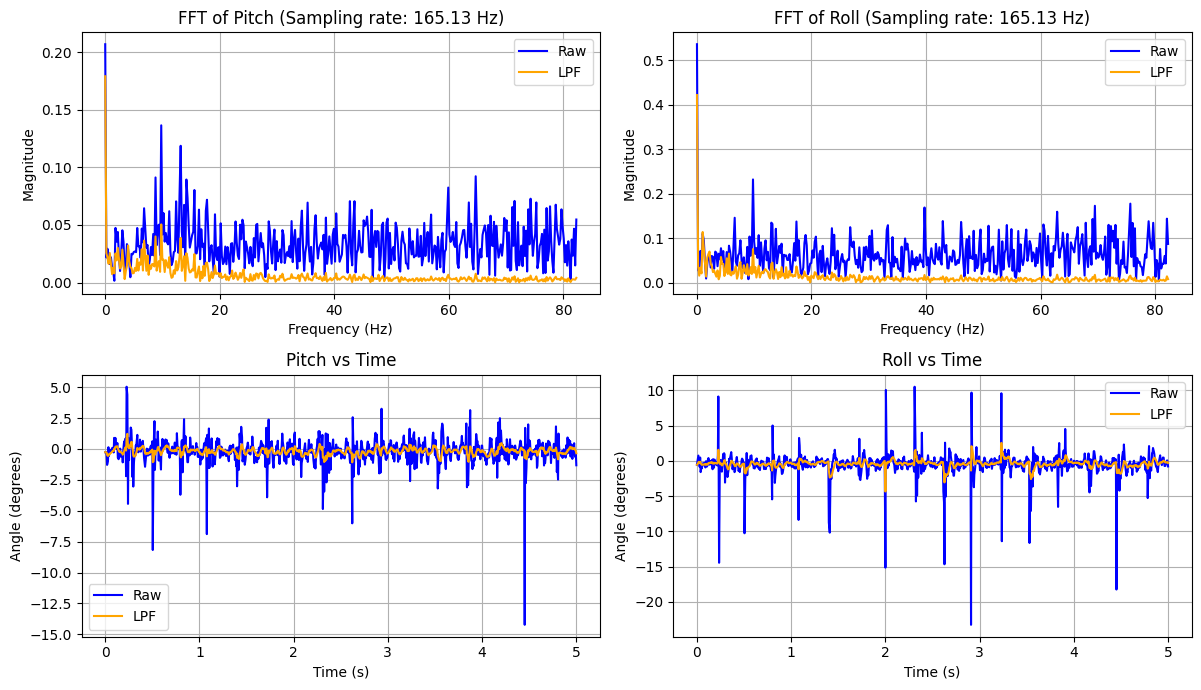

In [182]:
# Compute FFT for each axis
fft_raw_p = np.abs(fft(r_p))
fft_raw_r = np.abs(fft(r_r))
fft_filt_p = np.abs(fft(f_p))
fft_filt_r = np.abs(fft(f_r))

# Normalize FFT magnitudes
fft_raw_p_norm = fft_raw_p[:N//2] / N
fft_raw_r_norm = fft_raw_r[:N//2] / N
fft_filt_p_norm = fft_filt_p[:N//2] / N
fft_filt_r_norm = fft_filt_r[:N//2] / N

# Plot FFT for Pitch and Roll
fig, axes = plt.subplots(2, 2, figsize=(12,7))

# Pitch FFT
ax = axes[0, 0]
ax.plot(freq, fft_raw_p_norm, label='Raw', color='blue')
ax.plot(freq, fft_filt_p_norm, label='LPF', color='orange')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude')
ax.set_title(f'FFT of Pitch (Sampling rate: {sampling_rate:.2f} Hz)')
ax.grid(True)
ax.legend()

# Roll FFT
ax = axes[0,1]
ax.plot(freq, fft_raw_r_norm, label='Raw', color='blue')
ax.plot(freq, fft_filt_r_norm, label='LPF', color='orange')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude')
ax.set_title(f'FFT of Roll (Sampling rate: {sampling_rate:.2f} Hz)')
ax.grid(True)
ax.legend()

# Pitch Time
ax = axes[1, 0]
ax.plot(t, r_p, label='Raw', color='blue')
ax.plot(t, f_p, label='LPF', color='orange')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (degrees)')
ax.set_title('Pitch vs Time')
ax.grid(True)
ax.legend()

# Roll Time
ax = axes[1, 1]
ax.plot(t, r_r, label='Raw', color='blue')
ax.plot(t, f_r, label='LPF', color='orange')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (degrees)')
ax.set_title('Roll vs Time')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


In [275]:
f_cutoff = 5.0
rc = 1.0 / (2 * np.pi * f_cutoff)
alpha = dt / (rc + dt)
print(f"Low-pass filter alpha: {alpha:.4f}")

Low-pass filter alpha: 0.1598


## Gyroscope

In [339]:
times = []
gyroR = []
gyroP = []
gyroY = []

def gyro_notification_handler(sender, data: bytearray):
    s = ble.bytearray_to_string(data).split("|")
    if len(s) == 4:
        t = float(s[0][2:])
        r = float(s[1][2:])
        p = float(s[2][2:])
        y = float(s[3][2:])
        times.append(t)
        gyroR.append(r)
        gyroP.append(p)
        gyroY.append(y)

        print (f"T={t:7.2f}   r={r:7.2f}   p={p:7.2f}   y={y:7.2f}")

In [341]:
ble.start_notify(ble.uuid["RX_STRING"], gyro_notification_handler)

In [342]:
times = []
gyroR = []
gyroP = []
gyroY = []

ble.send_command(CMD.START_COLLECT_DATA, "")
time.sleep(10)
ble.send_command(CMD.GET_GYRO_READINGS, "")

T=778161.00   r=  -0.00   p=  -0.01   y=  -0.01
T=778166.00   r=  -0.02   p=   0.01   y=   0.00
T=778169.00   r=  -0.02   p=  -0.00   y=  -0.00
T=778176.00   r=  -0.04   p=  -0.01   y=  -0.01
T=778179.00   r=  -0.04   p=  -0.00   y=  -0.01
T=778184.00   r=  -0.05   p=   0.01   y=  -0.02
T=778187.00   r=  -0.06   p=  -0.01   y=  -0.02
T=778192.00   r=  -0.07   p=   0.01   y=  -0.03
T=778195.00   r=  -0.07   p=  -0.01   y=  -0.03
T=778203.00   r=  -0.09   p=   0.03   y=  -0.01
T=778206.00   r=  -0.10   p=  -0.02   y=  -0.01
T=778209.00   r=  -0.10   p=   0.04   y=   0.00
T=778212.00   r=  -0.09   p=  -0.03   y=  -0.00
T=778220.00   r=  -0.11   p=   0.06   y=  -0.01
T=778223.00   r=  -0.11   p=  -0.06   y=  -0.02
T=778226.00   r=  -0.11   p=   0.06   y=  -0.01
T=778229.00   r=  -0.11   p=  -0.06   y=  -0.01
T=778234.00   r=  -0.12   p=   0.06   y=  -0.01
T=778237.00   r=  -0.12   p=  -0.07   y=  -0.02
T=778241.00   r=  -0.12   p=   0.07   y=  -0.01
T=778244.00   r=  -0.12   p=  -0.07   y=

## Comparation

In [343]:
ble.stop_notify(ble.uuid["RX_STRING"])

In [344]:
ble.start_notify(ble.uuid["RX_STRING"], accl_notification_handler)

In [345]:
times = []
accX = []
accY = []
accZ = []
raw_pitch = []
raw_roll = []
filt_pitch = []
filt_roll = []

ble.send_command(CMD.GET_ACCL_READINGS, "")

T=778161.00   x= -41.99   y= -12.21   z=1009.76   pitch=  -2.38°   roll=  -0.69°  filt_pitch=  -2.38°   filt_roll=  -0.69°
T=778166.00   x= -48.83   y= -11.72   z=1010.74   pitch=  -2.77°   roll=  -0.66°  filt_pitch=  -2.44°   filt_roll=  -0.69°
T=778169.00   x= -55.17   y= -13.67   z=1018.55   pitch=  -3.10°   roll=  -0.77°  filt_pitch=  -2.54°   filt_roll=  -0.70°
T=778176.00   x= -55.17   y=  -6.83   z=1013.18   pitch=  -3.12°   roll=  -0.39°  filt_pitch=  -2.62°   filt_roll=  -0.65°
T=778179.00   x= -60.06   y= -12.21   z=1020.51   pitch=  -3.37°   roll=  -0.69°  filt_pitch=  -2.74°   filt_roll=  -0.66°
T=778184.00   x= -61.03   y= -13.67   z=1016.60   pitch=  -3.44°   roll=  -0.77°  filt_pitch=  -2.84°   filt_roll=  -0.68°
T=778187.00   x= -53.71   y= -17.58   z=1030.76   pitch=  -2.98°   roll=  -0.98°  filt_pitch=  -2.86°   filt_roll=  -0.72°
T=778192.00   x= -50.78   y=  -8.30   z=1003.42   pitch=  -2.90°   roll=  -0.47°  filt_pitch=  -2.87°   filt_roll=  -0.68°
T=778195.00   x=

In [ ]:
# Sample frequency: 3000 microseconds (333.33 Hz)
t_f1 = t
r_p_f1 = r_p
r_r_f1 = r_r
f_p_f1 = f_p
f_r_f1 = f_r
g_p_f1 = g_p
g_r_f1 = g_r

In [276]:
# Sample frequency: 30000 microseconds (33.33 Hz)
t_f2 = t
r_p_f2 = r_p
r_r_f2 = r_r
f_p_f2 = f_p
f_r_f2 = f_r
g_p_f2 = g_p
g_r_f2 = g_r

## Complementary Filter

In [346]:
times = []
compR = []
compP = []


def comp_notification_handler(sender, data: bytearray):
    s = ble.bytearray_to_string(data).split("|")
    if len(s) == 3:
        t = float(s[0][2:])
        r = float(s[1][2:])
        p = float(s[2][2:])
        times.append(t)
        compR.append(r)
        compP.append(p)

        print (f"T={t:7.2f}   r={r:7.2f}   p={p:7.2f}")

In [347]:
ble.stop_notify(ble.uuid["RX_STRING"])

In [348]:
ble.start_notify(ble.uuid["RX_STRING"], comp_notification_handler)

In [349]:
times = []
compR = []
compP = []

ble.send_command(CMD.GET_COMP_READINGS, "")

T=778161.00   r=  -0.11   p=  -0.37
T=778166.00   r=  -0.21   p=  -0.67
T=778169.00   r=  -0.28   p=  -0.95
T=778176.00   r=  -0.35   p=  -1.19
T=778179.00   r=  -0.40   p=  -1.41
T=778184.00   r=  -0.45   p=  -1.63
T=778187.00   r=  -0.49   p=  -1.81
T=778192.00   r=  -0.53   p=  -1.96
T=778195.00   r=  -0.54   p=  -2.11
T=778203.00   r=  -0.56   p=  -2.25
T=778206.00   r=  -0.56   p=  -2.34
T=778209.00   r=  -0.56   p=  -2.44
T=778212.00   r=  -0.56   p=  -2.52
T=778220.00   r=  -0.57   p=  -2.62
T=778223.00   r=  -0.57   p=  -2.68
T=778226.00   r=  -0.57   p=  -2.73
T=778229.00   r=  -0.57   p=  -2.75
T=778234.00   r=  -0.57   p=  -2.77
T=778237.00   r=  -0.58   p=  -2.79
T=778241.00   r=  -0.58   p=  -2.82
T=778244.00   r=  -0.59   p=  -2.85
T=778249.00   r=  -0.60   p=  -2.87
T=778252.00   r=  -0.61   p=  -2.88
T=778257.00   r=  -0.61   p=  -2.92
T=778260.00   r=  -0.61   p=  -2.94
T=778268.00   r=  -0.64   p=  -2.98
T=778271.00   r=  -0.64   p=  -2.98
T=778274.00   r=  -0.64   p=

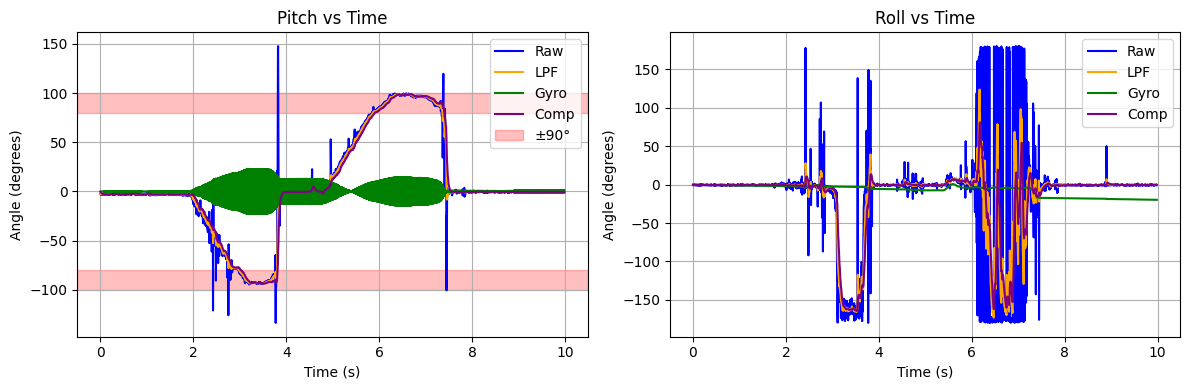

In [351]:
t = np.array(times)
t = t - t[0]
t = t / 1000.0
r_p = np.array(raw_pitch)
r_r = np.array(raw_roll)
f_p = np.array(filt_pitch)
f_r = np.array(filt_roll)
g_p = np.array(gyroP)
g_r = np.array(gyroR)
c_p = np.array(compP)
c_r = np.array(compR)


SAMPLE_INTERVAL = 10000

# Plot  Pitch and Roll
fig, axes = plt.subplots(1, 2, figsize=(12,4))
title = f"Sampling rate: {1./(SAMPLE_INTERVAL*1e-6):.2f} Hz"

# Pitch Time
ax = axes[0]
ax.plot(t, r_p, label='Raw', color='blue')
ax.plot(t, f_p, label='LPF', color='orange')
ax.plot(t, g_p, label='Gyro', color='green')
ax.plot(t, c_p, label='Comp', color='purple')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (degrees)')
ax.set_title('Pitch vs Time')
band = 10
ax.axhspan(90-band, 90+band, alpha=0.25, color='red', label='±90°')
ax.axhspan(-90-band, -90+band, alpha=0.25, color='red')
ax.grid(True)
ax.legend()

# Roll Time
ax = axes[1]
ax.plot(t, r_r, label='Raw', color='blue')
ax.plot(t, f_r, label='LPF', color='orange')
ax.plot(t, g_r, label='Gyro', color='green')
ax.plot(t, c_r, label='Comp', color='purple')
# band = 10
# ax.axhspan(90-band, 90+band, alpha=0.25, color='red', label='±90°')
# ax.axhspan(-90-band, -90+band, alpha=0.25, color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (degrees)')
ax.set_title('Roll vs Time')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

## Sample Data

In [374]:
times = []

def time_notification_handler(sender, data: bytearray):
    s = ble.bytearray_to_string(data).split("|")
    if len(s) == 1:
        t = float(s[0][2:])
        times.append(t)
        print("Time(ms) =", t)

In [381]:
ble.stop_notify(ble.uuid["RX_STRING"])

In [375]:
ble.start_notify(ble.uuid["RX_STRING"], time_notification_handler)

In [ ]:
times = []

ble.send_command(CMD.START_COLLECT_DATA, "")
time.sleep(5)
ble.send_command(CMD.SEND_TIME_DATA, "")

Time(ms) = 654120.0
Time(ms) = 654123.0
Time(ms) = 654125.0
Time(ms) = 654132.0
Time(ms) = 654134.0
Time(ms) = 654138.0
Time(ms) = 654140.0
Time(ms) = 654142.0
Time(ms) = 654149.0
Time(ms) = 654152.0
Time(ms) = 654154.0
Time(ms) = 654156.0
Time(ms) = 654161.0
Time(ms) = 654163.0
Time(ms) = 654165.0
Time(ms) = 654168.0
Time(ms) = 654170.0
Time(ms) = 654172.0
Time(ms) = 654177.0
Time(ms) = 654179.0
Time(ms) = 654186.0
Time(ms) = 654188.0
Time(ms) = 654196.0
Time(ms) = 654198.0
Time(ms) = 654200.0
Time(ms) = 654205.0
Time(ms) = 654207.0
Time(ms) = 654214.0
Time(ms) = 654217.0
Time(ms) = 654224.0
Time(ms) = 654226.0
Time(ms) = 654233.0
Time(ms) = 654236.0
Time(ms) = 654238.0
Time(ms) = 654245.0
Time(ms) = 654248.0
Time(ms) = 654255.0
Time(ms) = 654257.0
Time(ms) = 654262.0
Time(ms) = 654264.0
Time(ms) = 654266.0
Time(ms) = 654270.0
Time(ms) = 654272.0
Time(ms) = 654276.0
Time(ms) = 654279.0
Time(ms) = 654281.0
Time(ms) = 654288.0
Time(ms) = 654290.0
Time(ms) = 654297.0
Time(ms) = 654300.0


In [382]:
ble.start_notify(ble.uuid["RX_STRING"], comp_notification_handler)

In [ ]:
times = []
compR = []
compP = []

ble.send_command(CMD.START_COLLECT_DATA, "")
time.sleep(5)
ble.send_command(CMD.GET_COMP_READINGS, "")

T=654120.00   r=  -0.11   p=  -0.07
T=654123.00   r=  -0.21   p=  -0.13
T=654125.00   r=  -0.30   p=  -0.18
T=654132.00   r=  -0.37   p=  -0.21
T=654134.00   r=  -0.42   p=  -0.24
T=654138.00   r=  -0.45   p=  -0.25
T=654140.00   r=  -0.47   p=  -0.27
T=654142.00   r=  -0.48   p=  -0.29
T=654149.00   r=  -0.48   p=  -0.33
T=654152.00   r=  -0.48   p=  -0.36
T=654154.00   r=  -0.49   p=  -0.39
T=654156.00   r=  -0.49   p=  -0.41
T=654161.00   r=  -0.50   p=  -0.41
T=654163.00   r=  -0.49   p=  -0.40
T=654165.00   r=  -0.49   p=  -0.38
T=654168.00   r=  -0.48   p=  -0.38
T=654170.00   r=  -0.49   p=  -0.38
T=654172.00   r=  -0.50   p=  -0.39
T=654177.00   r=  -0.51   p=  -0.39
T=654179.00   r=  -0.50   p=  -0.38
T=654186.00   r=  -0.51   p=  -0.39
T=654188.00   r=  -0.53   p=  -0.39
T=654196.00   r=  -0.58   p=  -0.39
T=654198.00   r=  -0.61   p=  -0.38
T=654200.00   r=  -0.62   p=  -0.39
T=654205.00   r=  -0.62   p=  -0.39
T=654207.00   r=  -0.63   p=  -0.41
T=654214.00   r=  -0.63   p=

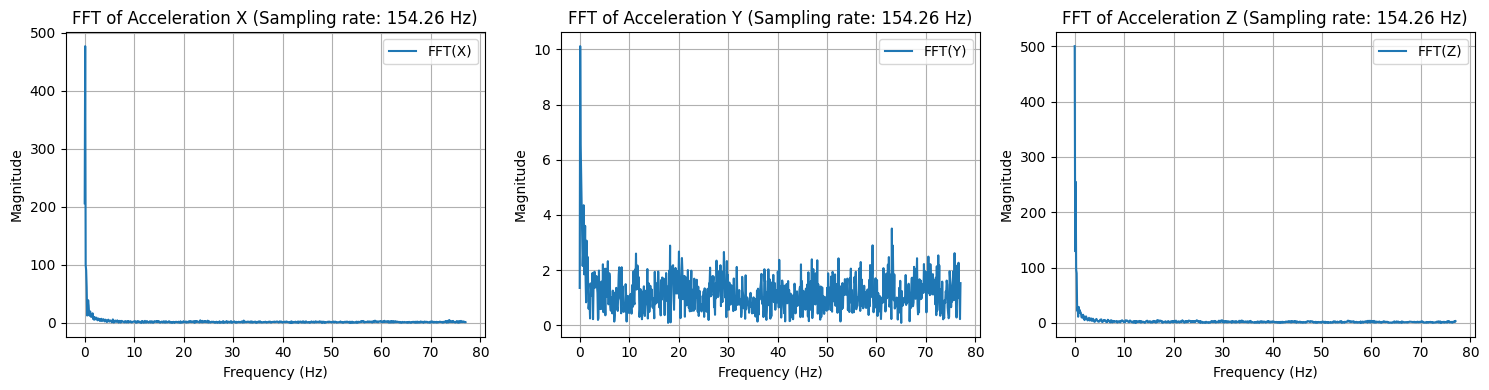

Sampling rate: 154.26 Hz
Number of samples: 1545
Total duration: 10.01 s
Peak frequency X: 0.10 Hz
Peak frequency Y: 0.10 Hz
Peak frequency Z: 0.20 Hz


In [66]:
# Plot FFT
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# X-axis FFT
ax = axes[0]
ax.plot(freq, fft_x_norm, label='FFT(X)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude')
ax.set_title(f'FFT of Acceleration X (Sampling rate: {sampling_rate:.2f} Hz)')
ax.grid(True)
ax.legend()

# Y-axis FFT
ax = axes[1]
ax.plot(freq, fft_y_norm, label='FFT(Y)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude')
ax.set_title(f'FFT of Acceleration Y (Sampling rate: {sampling_rate:.2f} Hz)')
ax.grid(True)
ax.legend()

# Z-axis FFT
ax = axes[2]
ax.plot(freq, fft_z_norm, label='FFT(Z)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude')
ax.set_title(f'FFT of Acceleration Z (Sampling rate: {sampling_rate:.2f} Hz)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Sampling rate: {sampling_rate:.2f} Hz")
print(f"Number of samples: {N}")
print(f"Total duration: {t[-1]:.2f} s")
print(f"Peak frequency X: {freq[np.argmax(fft_x_norm[1:])+1]:.2f} Hz")
print(f"Peak frequency Y: {freq[np.argmax(fft_y_norm[1:])+1]:.2f} Hz")
print(f"Peak frequency Z: {freq[np.argmax(fft_z_norm[1:])+1]:.2f} Hz")